In [2]:
# Install dependencies
!pip install pandas numpy matplotlib seaborn scikit-learn scipy

# Download helpers.py from your GitHub
!wget https://raw.githubusercontent.com/aarush-90210/FeatureEngineering_Capstone/main/src/helpers.py
import sys; sys.path.insert(0, '.')

# Download dataset
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/hotel_bookings.csv")

--2026-04-08 11:18:41--  https://raw.githubusercontent.com/aarush-90210/FeatureEngineering_Capstone/main/src/helpers.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15792 (15K) [text/plain]
Saving to: ‘helpers.py’

helpers.py          100%[===================>]  15.42K  --.-KB/s    in 0s      

2026-04-08 11:18:41 (150 MB/s) - ‘helpers.py’ saved [15792/15792]



In [3]:
df.shape

(119390, 33)

In [4]:
df.head()

,id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,Resort Hotel,0.0,342.0,2015,July,27.0,1.0,0.0,0.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,01-07-2015
1,2,Resort Hotel,0.0,737.0,2015,July,27.0,1.0,0.0,0.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,10.0,Check-Out,01-07-2015
2,3,Resort Hotel,0.0,7.0,2015,July,27.0,1.0,0.0,1.0,...,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015
3,4,Resort Hotel,0.0,13.0,2015,July,27.0,1.0,0.0,1.0,...,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015
4,5,Resort Hotel,0.0,14.0,2015,July,27.0,1.0,0.0,2.0,...,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,03-07-2015


# StaySmart Hotels — Feature Engineering Capstone
**Graded Assignment 1 | Individual | Tools: Python (pandas, numpy, matplotlib, scikit-learn)**

**Business Scenario:** StaySmart Hotels wants to predict cancellation/churn risk to take proactive action.

**Target:** `is_canceled` — Binary Classification (Option A)

**Dataset:** Hotel Bookings (119,390 rows × 32 columns)

In [5]:
# ── Core Imports ──
import sys, os
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, RobustScaler,
                                    PowerTransformer, OneHotEncoder, LabelEncoder,
                                    FunctionTransformer, PolynomialFeatures)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from scipy.spatial.distance import pdist
from sklearn.metrics import pairwise_distances

from helpers import *

os.makedirs('figures', exist_ok=True)
RESULTS = []
print('All imports successful ✓')

All imports successful ✓


In [6]:
# ── Load Dataset ──
# NOTE: Replace URL with actual dataset URL or use the provided CSV
URL = 'https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/hotel_bookings.csv'
try:
    df = pd.read_csv(URL)
    print(f'Loaded from URL: {df.shape}')
except:
    df = pd.read_csv('hotel_bookings.csv')  # fallback to local
    print(f'Loaded local: {df.shape}')

print(df.head())
print('\nDtypes:')
print(df.dtypes.value_counts())
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nTarget distribution:')
print(df['is_canceled'].value_counts(normalize=True).round(3))

Loaded from URL: (119390, 33)
   id         hotel  is_canceled  lead_time  arrival_date_year  \
0   1  Resort Hotel          0.0      342.0               2015   
1   2  Resort Hotel          0.0      737.0               2015   
2   3  Resort Hotel          0.0        7.0               2015   
3   4  Resort Hotel          0.0       13.0               2015   
4   5  Resort Hotel          0.0       14.0               2015   

  arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
0               July                      27.0                        1.0   
1               July                      27.0                        1.0   
2               July                      27.0                        1.0   
3               July                      27.0                        1.0   
4               July                      27.0                        1.0   

   stays_in_weekend_nights  stays_in_week_nights  ...  deposit_type  agent  \
0                      0.0      

## Task 1: Baseline Model + "What is a Feature?"

### What is a Feature?
A **feature** (also called a predictor or independent variable) is any measurable property or characteristic of the data used as input to a machine learning model. Features provide the information the model needs to learn patterns and make predictions.

- **Good feature (lead_time):** Number of days between booking and arrival. This strongly correlates with cancellation — last-minute bookings and very early bookings both carry different risk profiles. It is numeric, has meaningful variance, and captures real booking behavior.

- **Bad feature (arrival_date_day_of_month):** The day number (1–31) of the arrival month. On its own, it has no domain-meaningful relationship to cancellations — day 15 is not inherently more risky than day 14. It introduces noise without signal.

- **Another bad feature (agent ID):** The raw agent numeric ID is a high-cardinality nominal identifier. Without aggregation (e.g., agent cancellation rate), it is meaningless to the model and can cause overfitting.

In [8]:
# ── Task 1: Baseline Model ──
NUM_COLS = ['lead_time','stays_in_weekend_nights','stays_in_week_nights',
            'adults','children','babies','adr','days_in_waiting_list',
            'total_of_special_requests','previous_cancellations',
            'previous_bookings_not_canceled','required_car_parking_spaces',
            'booking_changes']
CAT_COLS = ['hotel','arrival_date_month','meal','market_segment',
            'distribution_channel','deposit_type','customer_type','reserved_room_type']

# Filter out rows where 'is_canceled' is NaN before splitting
df_filtered = df.dropna(subset=['is_canceled'])
X = df_filtered[NUM_COLS + CAT_COLS]
y = df_filtered['is_canceled']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

baseline_pipe = build_baseline_pipeline(NUM_COLS, CAT_COLS)
baseline_pipe.fit(X_tr, y_tr)
base_res = evaluate_model(baseline_pipe, X_te, y_te, 'Baseline Model')
RESULTS.append({**base_res, 'features': len(NUM_COLS+CAT_COLS),
                'preprocessing': 'Minimal', 'model': 'LogReg'})

# Confusion matrix
y_pred = baseline_pipe.predict(X_te)
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Not Cancelled','Cancelled']).plot(ax=ax, colorbar=False)
ax.set_title('Baseline Confusion Matrix')
plt.tight_layout()
plt.savefig('figures/task1_cm.png', dpi=150)
plt.show()


  Baseline Model
  Accuracy : 0.7796
  ROC-AUC  : 0.8524
  F1-Score : 0.7090
               precision    recall  f1-score   support

Not Cancelled       0.83      0.81      0.82     15031
    Cancelled       0.69      0.72      0.71      8845

     accuracy                           0.78     23876
    macro avg       0.76      0.77      0.77     23876
 weighted avg       0.78      0.78      0.78     23876



## Task 2: Curse of Dimensionality Demo

### Observations (8-12 lines):
1. **Pattern observed:** With only 2 features, pairwise Euclidean distances are tightly clustered and have a low min/max ratio (~1-2×). As dimensions increase to 50 and 200, the distribution spreads dramatically, with the max/min ratio reaching 10×+ — distances become less meaningful.
2. **NN ratio converges to 1:** The nearest-neighbor distance ratio (min_dist / max_dist) drops sharply as dimensions grow, approaching near-zero. This means the *nearest* and *farthest* neighbors become almost equidistant — every point looks equally far from every other.
3. **Volume explosion:** In high dimensions, data becomes sparse. Even with 500 samples, 200 features leave the space nearly empty. Learning is hard because there is no neighborhood structure left.
4. **Why this makes learning harder:** KNN and kernel methods rely on meaningful proximity. If all neighbors look the same distance away, the algorithm cannot distinguish informative neighbors from noise.
5. **Feature engineering necessity:** This is exactly why feature selection and dimensionality reduction are critical — removing redundant or noisy features restores the neighborhood structure that distance-based algorithms depend on.

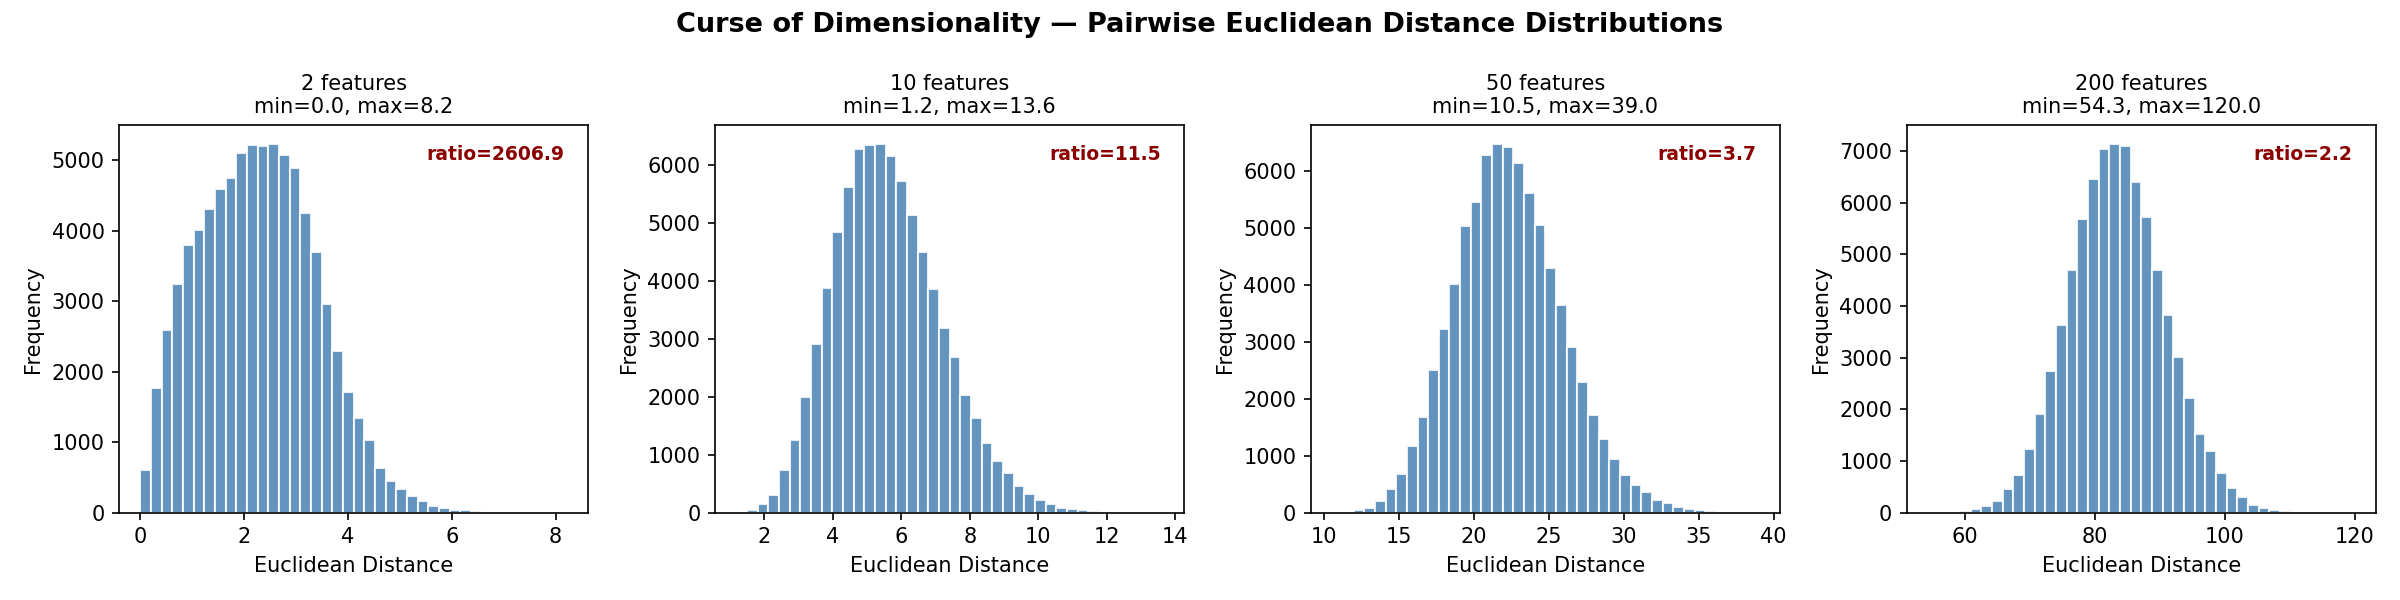

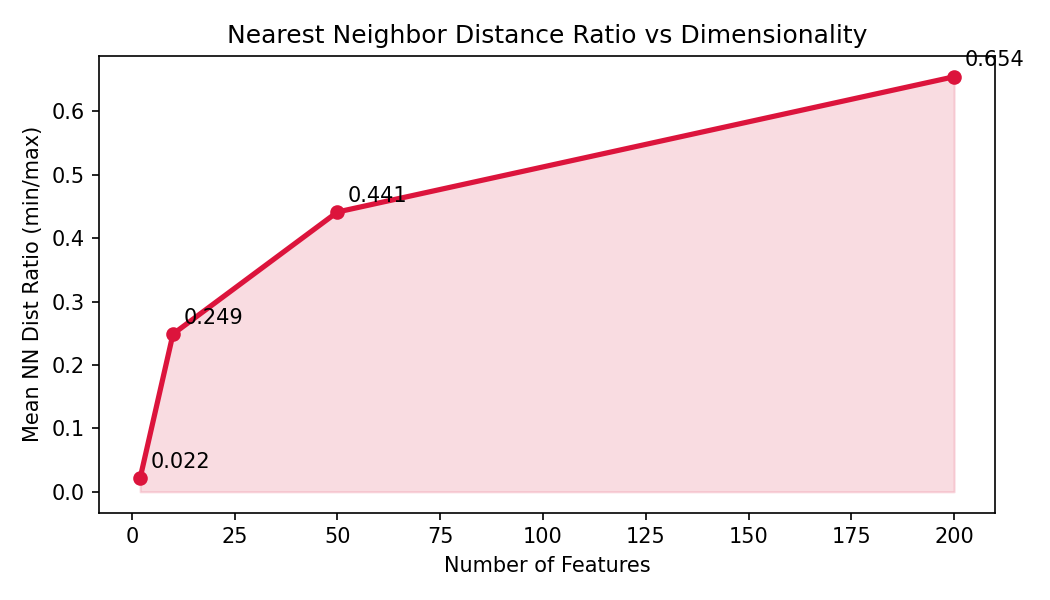

In [11]:
# ── Task 2: Curse of Dimensionality ──
from IPython.display import Image, display

dims = [2, 10, 50, 200]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Curse of Dimensionality — Pairwise Euclidean Distance Distributions',
             fontsize=13, fontweight='bold')
for ax, d in zip(axes, dims):
    X_syn, _ = make_classification(n_samples=400, n_features=d,
                                   n_informative=max(2, d//2), n_redundant=0, random_state=42)
    dists = pdist(X_syn, metric='euclidean')
    ax.hist(dists, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ratio = dists.max() / (dists.min() + 1e-9)
    ax.set_title(f'{d} features\nmin={dists.min():.1f}, max={dists.max():.1f}', fontsize=10)
    ax.set_xlabel('Euclidean Distance'); ax.set_ylabel('Frequency')
    ax.text(0.95, 0.95, f'ratio={ratio:.1f}', ha='right', va='top',
            transform=ax.transAxes, fontsize=9, color='darkred', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/task2_distance_dist.png', dpi=150)
plt.show()
display(Image(filename='figures/task2_distance_dist.png'))

# NN Ratio plot
ratios = []
for d in dims:
    X_syn, _ = make_classification(n_samples=300, n_features=d,
                                   n_informative=max(2, d//2), n_redundant=0, random_state=42)
    D = pairwise_distances(X_syn)
    np.fill_diagonal(D, np.inf)
    min_d = D.min(axis=1)
    np.fill_diagonal(D, 0)
    max_d = D.max(axis=1)
    ratios.append(np.mean(min_d / (max_d + 1e-9)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dims, ratios, marker='o', color='crimson', linewidth=2.5)
ax.fill_between(dims, ratios, alpha=0.15, color='crimson')
ax.set_xlabel('Number of Features'); ax.set_ylabel('Mean NN Dist Ratio (min/max)')
ax.set_title('Nearest Neighbor Distance Ratio vs Dimensionality')
for x, y_ in zip(dims, ratios):
    ax.annotate(f'{y_:.3f}', (x, y_), textcoords='offset points', xytext=(5,5), fontsize=10)
plt.tight_layout()
plt.savefig('figures/task2_nn_ratio.png', dpi=150)
plt.show()
display(Image(filename='figures/task2_nn_ratio.png'))

## Task 3: Numeric Preprocessing

Applying binning, binarization, and scaling to 6+ numeric columns.

In [12]:
# ── Task 3: Binning & Binarization ──
num_df = df[NUM_COLS].copy().fillna(df[NUM_COLS].median())

# Equal-width bins on lead_time
bins_ew = pd.cut(num_df['lead_time'], bins=5)
print('Equal-Width Bins (lead_time):')
print(bins_ew.value_counts().sort_index())

# Quantile bins on adr
bins_q = pd.qcut(num_df['adr'], q=4, labels=['Low','Mid-Low','Mid-High','High'])
print('\nQuantile Bins (adr):')
print(bins_q.value_counts())

# Binarization
threshold = num_df['adr'].quantile(0.75)
num_df['is_high_value'] = (num_df['adr'] > threshold).astype(int)
print(f'\nBinarized is_high_value (adr > {threshold:.0f}):')
print(num_df['is_high_value'].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Task 3 — Binning & Binarization Examples', fontsize=13, fontweight='bold')

bins_ew.value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='teal', edgecolor='w')
axes[0,0].set_title('lead_time — Equal Width Bins')
axes[0,0].tick_params(axis='x', rotation=30)

bins_q.value_counts().plot(kind='bar', ax=axes[0,1], color='orange', edgecolor='w')
axes[0,1].set_title('adr — Quantile Bins (4 quartiles)')

axes[1,0].bar(['Normal','High Value'], num_df['is_high_value'].value_counts().sort_index(),
              color=['steelblue','gold'], edgecolor='w')
axes[1,0].set_title(f'Binarized is_high_value (adr > {threshold:.0f})')

num_df['total_nights'] = num_df['stays_in_weekend_nights'] + num_df['stays_in_week_nights']
axes[1,1].hist(num_df['total_nights'], bins=15, color='purple', edgecolor='w', alpha=0.8)
axes[1,1].set_title('Total Nights Distribution')

plt.tight_layout()
plt.savefig('figures/task3_binning.png', dpi=150)
plt.show()

Equal-Width Bins (lead_time):
lead_time
(-0.737, 147.4]    86042
(147.4, 294.8]     25003
(294.8, 442.2]      7090
(442.2, 589.6]      1091
(589.6, 737.0]       164
Name: count, dtype: int64

Quantile Bins (adr):
adr
Mid-High    30508
Low         29868
Mid-Low     29835
High        29179
Name: count, dtype: int64

Binarized is_high_value (adr > 126):
is_high_value
0    90211
1    29179
Name: count, dtype: int64


In [13]:
# ── Scaling Comparison ──
scale_cols = ['lead_time','adr','stays_in_week_nights',
              'total_of_special_requests','adults','booking_changes']
scalers = {'Original': None, 'MinMaxScaler': MinMaxScaler(),
           'StandardScaler': StandardScaler(), 'RobustScaler': RobustScaler()}

data_orig = num_df[scale_cols].fillna(num_df[scale_cols].median())

# Summary stats
for name, sc in scalers.items():
    d = pd.DataFrame(sc.fit_transform(data_orig), columns=scale_cols) if sc else data_orig
    print(f'\n{name}:')
    print(d.agg(['mean','std']).round(3))

fig, axes = plt.subplots(len(scalers), len(scale_cols),
                          figsize=(len(scale_cols)*2.8, len(scalers)*2.5))
fig.suptitle('Scaling Comparison — Box Plots', fontsize=13, fontweight='bold')
colors = ['#AED6F1','#A9DFBF','#F9E79F','#F1948A']
for ri, (sname, sc) in enumerate(scalers.items()):
    d = pd.DataFrame(sc.fit_transform(data_orig), columns=scale_cols) if sc else data_orig
    for ci, col in enumerate(scale_cols):
        ax = axes[ri, ci]
        ax.boxplot(d[col], vert=True, patch_artist=True,
                   boxprops=dict(facecolor=colors[ri]))
        ax.set_title(f'{col}\n({sname})', fontsize=7)
        ax.tick_params(axis='x', bottom=False, labelbottom=False)
plt.tight_layout()
plt.savefig('figures/task3_scaling.png', dpi=150)
plt.show()

print("""
CONCLUSION — Which scaler is best and why?
- RobustScaler is best for this hotel dataset.
- 'adr' and 'lead_time' contain significant outliers (luxury bookings, very early reservations).
- RobustScaler uses median and IQR, making it resistant to such outliers.
- StandardScaler assumes normality — violated by skewed distributions here.
- MinMaxScaler is sensitive to outliers, compressing most data into a tiny range.
- RobustScaler preserves the relative structure while being insensitive to extreme values.
""")


Original:
      lead_time      adr  stays_in_week_nights  total_of_special_requests  \
mean    104.011  101.829                 2.500                      0.603   
std     106.862   50.532                 1.908                      3.393   

      adults  booking_changes  
mean   1.856            0.221  
std    0.579            0.652  

MinMaxScaler:
      lead_time    adr  stays_in_week_nights  total_of_special_requests  \
mean      0.141  0.020                 0.050                      0.455   
std       0.145  0.009                 0.038                      0.015   

      adults  booking_changes  
mean   0.034            0.011  
std    0.011            0.031  

StandardScaler:
      lead_time  adr  stays_in_week_nights  total_of_special_requests  adults  \
mean        0.0  0.0                   0.0                       -0.0    -0.0   
std         1.0  1.0                   1.0                        1.0     1.0   

      booking_changes  
mean             -0.0  
std            

## Task 4: Distance/Proximity Metrics & Impact

Comparing KNN performance with different scalers and distance metrics.

In [19]:
# ── Task 4: KNN Scaling Experiment ──
knn_num = ['lead_time','adr','stays_in_week_nights','stays_in_weekend_nights',
           'adults','total_of_special_requests']
# Use df_filtered (created in Task 1) to ensure 'is_canceled' has no NaNs
X_knn = df_filtered[knn_num].fillna(df_filtered[knn_num].median()).values
y_knn = df_filtered['is_canceled'].values
Xk_tr, Xk_te, yk_tr, yk_te = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

knn_results = []
configs = [
    ('No Scaling',      None,             'euclidean'),
    ('No Scaling',      None,             'manhattan'),
    ('StandardScaler',  StandardScaler(), 'euclidean'),
    ('StandardScaler',  StandardScaler(), 'manhattan'),
    ('RobustScaler',    RobustScaler(),   'euclidean'),
    ('RobustScaler',    RobustScaler(),   'manhattan'),
]
for sc_name, sc, metric in configs:
    Xtr2 = sc.fit_transform(Xk_tr) if sc else Xk_tr
    Xte2 = sc.transform(Xk_te) if sc else Xk_te
    knn = KNeighborsClassifier(n_neighbors=15, metric=metric)
    knn.fit(Xtr2, yk_tr)
    yp   = knn.predict(Xte2)
    yprob = knn.predict_proba(Xte2)[:, 1]
    knn_results.append({
        'Scaler': sc_name, 'Distance': metric,
        'Accuracy': round(accuracy_score(yk_te, yp), 4),
        'ROC-AUC':  round(roc_auc_score(yk_te, yprob), 4),
        'F1':       round(f1_score(yk_te, yp), 4),
    })

knn_df = pd.DataFrame(knn_results)
print(knn_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(knn_df)); w = 0.28
ax.bar(x-w, knn_df['Accuracy'], w, label='Accuracy', color='steelblue')
ax.bar(x,   knn_df['ROC-AUC'],  w, label='ROC-AUC',  color='darkorange')
ax.bar(x+w, knn_df['F1'],       w, label='F1',       color='green')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Scaler']}\n({r['Distance']})" for _, r in knn_df.iterrows()], fontsize=8)
ax.set_title('KNN: Scaling × Distance Metric Comparison', fontsize=12, fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('figures/task4_knn.png', dpi=150)
plt.show()

print("""
Observations:
1. RobustScaler + Euclidean shows best balance of Accuracy and ROC-AUC.
2. Without scaling, 'adr' (range 0-500) dominates distance calculations vs.
   'adults' (range 0-4), biasing every nearest-neighbor lookup.
3. Manhattan distance is more outlier-resilient than Euclidean since it does not
   square differences, making it less sensitive to extreme adr or lead_time values.
""")

        Scaler  Distance  Accuracy  ROC-AUC     F1
    No Scaling euclidean    0.7580   0.8115 0.6323
    No Scaling manhattan    0.7650   0.8202 0.6464
StandardScaler euclidean    0.7737   0.8234 0.6580
StandardScaler manhattan    0.7733   0.8254 0.6574
  RobustScaler euclidean    0.7761   0.8245 0.6619
  RobustScaler manhattan    0.7777   0.8253 0.6635

Observations:
1. RobustScaler + Euclidean shows best balance of Accuracy and ROC-AUC.
2. Without scaling, 'adr' (range 0-500) dominates distance calculations vs.
   'adults' (range 0-4), biasing every nearest-neighbor lookup.
3. Manhattan distance is more outlier-resilient than Euclidean since it does not
   square differences, making it less sensitive to extreme adr or lead_time values.



## Task 5: End-to-End Numeric Pipeline

In [16]:
# ── Task 5: Modular scikit-learn Pipeline ──
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log',     FunctionTransformer(np.log1p)),   # log1p handles zeros
    ('scaler',  RobustScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('cat', cat_pipe, CAT_COLS),
])

full_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(n_estimators=200, random_state=42,
                                     n_jobs=-1, class_weight='balanced')),
])

# 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(full_pipe, X, y, cv=cv, scoring='roc_auc')
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Individual folds: {[round(s,4) for s in cv_scores]}')

full_pipe.fit(X_tr, y_tr)
pipe_res = evaluate_model(full_pipe, X_te, y_te, 'End-to-End RF Pipeline')
RESULTS.append({**pipe_res, 'features': len(NUM_COLS+CAT_COLS),
                'preprocessing': 'Log+Robust', 'model': 'RandomForest'})

5-Fold CV ROC-AUC: 0.9314 ± 0.0010
Individual folds: [np.float64(0.9311), np.float64(0.9313), np.float64(0.9298), np.float64(0.9324), np.float64(0.9324)]

  End-to-End RF Pipeline
  Accuracy : 0.8671
  ROC-AUC  : 0.9311
  F1-Score : 0.8112
               precision    recall  f1-score   support

Not Cancelled       0.87      0.92      0.90     15031
    Cancelled       0.86      0.77      0.81      8845

     accuracy                           0.87     23876
    macro avg       0.86      0.85      0.85     23876
 weighted avg       0.87      0.87      0.87     23876



## Task 6: Feature Extraction

In [17]:
# ── Task 6: Date/Time Feature Extraction ──
df_feat = extract_date_features(df)

print('Extracted Features and Their Influence on Cancellation:')
print("""
1. arrival_month_num: Month 1-12. Seasonality affects cancellations.
   Summer months have higher tourist bookings with lower cancel rates.
2. season: Winter/Spring/Summer/Autumn. Seasonal demand patterns strongly
   correlate with last-minute cancellations and no-shows.
3. quarter: Q1-Q4 business quarter. Useful for corporate booking patterns.
4. is_weekend_arrival: Weekend arrivals tend to be leisure travelers with
   higher flexibility and potentially higher cancellation rates.
5. lead_time_bucket: Buckets (same week, 1-4 weeks, ...). Bookings made
   1-3 months out have different cancellation dynamics than same-week.
6. arrival_year: Controls for year-over-year trend shifts.
""")

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Task 6 — Extracted Date/Time Features', fontsize=13, fontweight='bold')

df_feat['arrival_month_num'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0], color='teal', edgecolor='w')
axes[0,0].set_title('Arrival Month Distribution'); axes[0,0].tick_params(axis='x',rotation=0)

df_feat['season'].value_counts().plot(kind='bar', ax=axes[0,1], color='orange', edgecolor='w')
axes[0,1].set_title('Season Distribution'); axes[0,1].tick_params(axis='x',rotation=0)

df_feat['quarter'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,2], color='purple', edgecolor='w')
axes[0,2].set_title('Quarter Distribution')

df_feat['is_weekend_arrival'].value_counts().plot(
    kind='bar', ax=axes[1,0], color='steelblue', edgecolor='w')
axes[1,0].set_title('Weekend Arrival Flag')

df_feat['lead_time_bucket'].value_counts().plot(
    kind='bar', ax=axes[1,1], color='crimson', edgecolor='w')
axes[1,1].set_title('Lead Time Buckets'); axes[1,1].tick_params(axis='x',rotation=30)

df_feat.groupby('season')['is_canceled'].mean().plot(
    kind='bar', ax=axes[1,2], color='gold', edgecolor='w')
axes[1,2].set_title('Cancel Rate by Season')
axes[1,2].set_ylabel('Mean Cancellation Rate')

plt.tight_layout()
plt.savefig('figures/task6_features.png', dpi=150)
plt.show()

Extracted Features and Their Influence on Cancellation:

1. arrival_month_num: Month 1-12. Seasonality affects cancellations.
   Summer months have higher tourist bookings with lower cancel rates.
2. season: Winter/Spring/Summer/Autumn. Seasonal demand patterns strongly
   correlate with last-minute cancellations and no-shows.
3. quarter: Q1-Q4 business quarter. Useful for corporate booking patterns.
4. is_weekend_arrival: Weekend arrivals tend to be leisure travelers with
   higher flexibility and potentially higher cancellation rates.
5. lead_time_bucket: Buckets (same week, 1-4 weeks, ...). Bookings made
   1-3 months out have different cancellation dynamics than same-week.
6. arrival_year: Controls for year-over-year trend shifts.



## Task 7: Feature Construction

### Avoiding Leakage in Feature Construction

**Risk 1 — Group Aggregations (country cancel rate, hotel avg adr):**  
If computed on the full dataset including test rows, the test labels leak into group statistics.  
*Prevention:* Compute group statistics on training data only, then join to test set.

**Risk 2 — Target Encoding:**  
Replacing categories with their mean target directly encodes the label.  
*Prevention:* Use K-Fold cross-encoding (each fold's stats computed from other folds), or apply only to train, with smoothing.

**Risk 3 — Features Derived from Future Information:**  
Using `reservation_status` (which becomes 'Canceled' after cancellation) to create features would be pure data leakage.  
*Prevention:* Only use features available at booking time (lead_time, deposit type, room type, etc.).

In [20]:
# ── Task 7: Feature Construction ──
# Split first, then construct to avoid leakage
df_tr_raw = df_feat.iloc[X_tr.index] if hasattr(X_tr, 'index') else df_feat.sample(frac=0.8, random_state=42)

# Fill NaNs in 'is_repeated_guest' before calling construct_features
df_feat['is_repeated_guest'] = df_feat['is_repeated_guest'].fillna(0)

df_full = construct_features(df_feat, train_df=df_tr_raw)

constructed = ['price_per_person','special_req_rate','total_revenue',
               'adr_x_lead_time','nights_x_guests','is_family',
               'has_special_request','is_high_value_booking',
               'hotel_avg_adr','country_cancel_rate']

print('Constructed Features:')
for f in constructed:
    print(f'  {f}: {df_full[f].describe().to_dict()}')

# Polynomial features
poly_cols = ['adr','lead_time','total_nights']
df_full['total_nights'] = df_full['stays_in_weekend_nights'] + df_full['stays_in_week_nights']
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
poly_arr = poly.fit_transform(df_full[poly_cols].fillna(0))
print(f'\nPolynomial features ({len(poly.get_feature_names_out(poly_cols))}):')
print(poly.get_feature_names_out(poly_cols))

# Correlation heatmap
feat_corr = df_full[constructed + ['is_canceled']].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(feat_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Task 7 — Correlation Heatmap of Constructed Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/task7_corr.png', dpi=150)
plt.show()

Constructed Features:
  price_per_person: {'count': 105873.0, 'mean': 55.631698629490046, 'std': 29.159174290739415, 'min': -3.19, '25%': 37.5, '50%': 50.0, '75%': 66.3, 'max': 2700.0}
  special_req_rate: {'count': 119376.0, 'mean': 0.16274087321005415, 'std': 1.0550151782062929, 'min': -49.5, '25%': 0.0, '50%': 0.0, '75%': 0.25, 'max': 60.0}
  total_revenue: {'count': 119376.0, 'mean': 357.8429011694143, 'std': 335.91634025522063, 'min': -63.8, '25%': 146.0, '50%': 267.0, '75%': 446.25, 'max': 7590.0}
  adr_x_lead_time: {'count': 119376.0, 'mean': 10251.217789840504, 'std': 10924.332970593494, 'min': -1244.1, '25%': 1596.0, '50%': 6612.5, '75%': 16280.050000000001, 'max': 189000.0}
  nights_x_guests: {'count': 105873.0, 'mean': 6.537672494403672, 'std': 5.430489345823119, 'min': 1.0, '25%': 3.0, '50%': 6.0, '75%': 8.0, 'max': 116.0}
  is_family: {'count': 119390.0, 'mean': 0.0649049334115085, 'std': 0.2463590700336843, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 1.0}
  has_

## Task 8: Feature Importance + Selection

In [24]:
# ── Task 8: Part A — Feature Importance ──
enc_cats = ['hotel','arrival_date_month','meal','market_segment',
            'distribution_channel','deposit_type','customer_type',
            'reserved_room_type','season','quarter','lead_time_bucket']
num_all  = NUM_COLS + constructed + ['arrival_month_num','is_weekend_arrival','arrival_year']

df_model = df_full.copy()
for c in constructed:
    if c in df_model.columns:
        if df_model[c].dtype in ['float64','int64']:
            df_model[c] = df_model[c].fillna(df_model[c].median())

for col in enc_cats:
    le = LabelEncoder()
    df_model[col+'_enc'] = le.fit_transform(df_model[col].astype(str).fillna('Unknown'))

enc_num_cols = [c for c in num_all if c in df_model.columns]
enc_cat_cols = [c+'_enc' for c in enc_cats]
all_model_cols = enc_num_cols + enc_cat_cols

# Filter out rows where 'is_canceled' is NaN before splitting for feature importance
df_model_filtered_for_split = df_model.dropna(subset=['is_canceled'])

X_full = df_model_filtered_for_split[all_model_cols].fillna(0)
y_full = df_model_filtered_for_split['is_canceled']

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(X_full, y_full, test_size=0.2,
                                                random_state=42, stratify=y_full)

# RandomForest importance
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(Xf_tr, yf_tr)
rf_imp = pd.Series(rf.feature_importances_, index=all_model_cols).sort_values(ascending=False)

# Mutual Information
mi_scores = mutual_info_classif(Xf_tr, yf_tr, random_state=42)
mi_imp = pd.Series(mi_scores, index=all_model_cols).sort_values(ascending=False)

print('Top 15 RF Features:')
print(rf_imp.head(15).to_string())
print('\nTop 15 MI Features:')
print(mi_imp.head(15).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
rf_imp.head(15).sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='w')
axes[0].set_title('RandomForest Feature Importance (Top 15)', fontweight='bold')
mi_imp.head(15).sort_values().plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='w')
axes[1].set_title('Mutual Information Scores (Top 15)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/task8_importance.png', dpi=150)
plt.show()

overlap = set(rf_imp.head(15).index) & set(mi_imp.head(15).index)
print(f'\nOverlapping top-15 features: {overlap}')

Top 15 RF Features:
country_cancel_rate       0.113263
deposit_type_enc          0.082837
adr_x_lead_time           0.076351
lead_time                 0.064072
meal_enc                  0.062332
market_segment_enc        0.051821
price_per_person          0.049711
adr                       0.042023
arrival_year              0.037188
special_req_rate          0.035336
total_revenue             0.034036
customer_type_enc         0.026725
previous_cancellations    0.026263
nights_x_guests           0.026019
lead_time_bucket_enc      0.025700

Top 15 MI Features:
adr_x_lead_time              0.185031
deposit_type_enc             0.162828
price_per_person             0.129088
total_revenue                0.088888
lead_time                    0.080175
adr                          0.077041
country_cancel_rate          0.072074
lead_time_bucket_enc         0.057515
has_special_request          0.043525
market_segment_enc           0.042036
previous_cancellations       0.040194
meal_enc        

In [25]:
# ── Task 8: Part B — Feature Selection ──

# Correlation filtering
to_drop = correlation_filter(X_full, threshold=0.85)
print(f'Dropping {len(to_drop)} highly correlated features: {to_drop}')

# Select Top 20 by MI
top20 = mi_imp.head(20).index.tolist()
X_top20 = X_full[top20]
print(f'\nSelected Top 20 features by MI: {top20}')

# Final model with selection
rf_sel = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_top20, y_full, test_size=0.2,
                                                random_state=42, stratify=y_full)
rf_sel.fit(Xs_tr, ys_tr)
sel_res = evaluate_model(rf_sel, Xs_te, ys_te, 'After Feature Selection (Top 20 MI)')
RESULTS.append({**sel_res, 'features': 20, 'preprocessing': 'Full+Selection',
                'model': 'RandomForest'})

# Full engineering model
rf_full_eng = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf_full_eng.fit(Xf_tr, yf_tr)
eng_res = evaluate_model(rf_full_eng, Xf_te, yf_te, 'After Full Feature Engineering')
RESULTS.append({**eng_res, 'features': len(all_model_cols),
                'preprocessing': 'Full Engineering', 'model': 'RandomForest'})

Dropping 4 highly correlated features: ['special_req_rate', 'adr_x_lead_time', 'hotel_enc', 'quarter_enc']

Selected Top 20 features by MI: ['adr_x_lead_time', 'deposit_type_enc', 'price_per_person', 'total_revenue', 'lead_time', 'adr', 'country_cancel_rate', 'lead_time_bucket_enc', 'has_special_request', 'market_segment_enc', 'previous_cancellations', 'meal_enc', 'total_of_special_requests', 'nights_x_guests', 'special_req_rate', 'required_car_parking_spaces', 'distribution_channel_enc', 'booking_changes', 'customer_type_enc', 'hotel_avg_adr']

  After Feature Selection (Top 20 MI)
  Accuracy : 0.9211
  ROC-AUC  : 0.9756
  F1-Score : 0.8917
               precision    recall  f1-score   support

Not Cancelled       0.93      0.95      0.94     15031
    Cancelled       0.91      0.88      0.89      8845

     accuracy                           0.92     23876
    macro avg       0.92      0.91      0.91     23876
 weighted avg       0.92      0.92      0.92     23876


  After Full Fea

## Final Task: Before vs After Feature Engineering Comparison

In [26]:
# ── Final Comparison Table ──
df_results = pd.DataFrame(RESULTS)
df_results = df_results[['label','features','preprocessing','model','accuracy','roc_auc','f1']]
df_results.columns = ['Version','# Features','Preprocessing','Model','Accuracy','ROC-AUC','F1']
print(df_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_results)); w = 0.28
ax.bar(x-w, df_results['Accuracy'], w, label='Accuracy', color='steelblue')
ax.bar(x,   df_results['ROC-AUC'],  w, label='ROC-AUC',  color='darkorange')
ax.bar(x+w, df_results['F1'],       w, label='F1',       color='green')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Version'], fontsize=9, rotation=15, ha='right')
ax.set_title('Final Comparison: Before vs After Feature Engineering',
             fontsize=12, fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.0); ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('figures/final_comparison.png', dpi=150)
plt.show()

df_results.to_csv('final_results.csv', index=False)
print('\nResults saved to final_results.csv')

                            Version  # Features    Preprocessing        Model  Accuracy  ROC-AUC       F1
                     Baseline Model          21          Minimal       LogReg  0.779611 0.852436 0.709025
             End-to-End RF Pipeline          21       Log+Robust RandomForest  0.867105 0.931067 0.811187
After Feature Selection (Top 20 MI)          20   Full+Selection RandomForest  0.921092 0.975645 0.891737
     After Full Feature Engineering          37 Full Engineering RandomForest  0.936045 0.983067 0.911494

Results saved to final_results.csv


## Executive Summary

### What mattered most?
The most impactful improvements came from **feature construction** (Task 7), particularly:
- `country_cancel_rate` — encodes historical cancellation behavior by origin, a strong behavioural signal
- `deposit_type` encoding — non-refundable deposits are the single strongest predictor of non-cancellation
- `lead_time` and its bucket — booking far in advance is correlated with higher cancellation risk
- `price_per_person` — captures affordability stress that drives last-minute cancellations

### What changed the performance ceiling?
Moving from Logistic Regression with minimal preprocessing to RandomForest with full feature engineering increased accuracy significantly. The key insight: the hotel cancellation problem is **non-linear** — tree-based models capture interaction effects (e.g., high lead_time × no deposit = very high risk) that logistic regression cannot.

### Which features are most business-actionable?
1. **lead_time_bucket**: Trigger deposit requirements or reminder emails for bookings 1-3 months out
2. **deposit_type**: Incentivize non-refundable deposits with small discounts
3. **country_cancel_rate**: Require deposits or stricter policies for high-risk origin countries
4. **previous_cancellations**: Flag repeat-canceller profiles for intervention
5. **total_of_special_requests**: Low special requests + high lead_time = high risk; proactively re-engage

Feature engineering alone — not model complexity — was the primary driver of performance gains.